In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [4]:
data = pd.read_csv("../data/Perioperative_Dataset_csv.csv")

C:\Users\hfarheen\AppData\Local\Temp\ipykernel_14052\4210234750.py:1: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("Perioperative_Dataset_csv.csv")


In [5]:
data = data.drop(columns = ['CASEDATE', 'Unnamed: 0'])

In [6]:
data.shape

(445897, 68)

In [7]:
data.columns

Index(['ID_NO_V', 'ENCRYPTED_MRNUMBER', 'ENCRYPTED_VISITID', 'CASENUMBER',
       'LOCATIONID', 'PATIENTTYPE', 'SURGEONID', 'SURGERY',
       'EMERGENCYCOLORCODE', 'PACKAGEPATIENT', 'CASEDESCRIPTIONSHORT',
       'WOUNDTYPE', 'SURGERYTYPEDESCRIPTION', 'ANESID1', 'ANESID2', 'ANESID3',
       'ALL_ANES', 'CARD_ANES', 'ANES_REQ', 'ASALEVEL', 'PROCEDUREDESCR_1',
       'OPERATINGSURGID_1', 'SPECIALTY_1', 'PROCSTATUS_1',
       'TOTALPROCEDURES_PERCASE', 'DOB', 'AGE', 'Age_Bracket',
       'Age_Bracket_Type', 'CASE_AGE_Y', 'CASE_AGE_D', 'AGE_RANGE',
       'ADULT_PED_D', 'SEX', 'ENCOUNTER_TYPE', 'ADMISSION_SOURCE_DESC',
       'ADMIT_DATE_TIME', 'DISCHARGE_DATE_TIME', 'LOS', 'LOS_Bracket',
       'DISCHARGE_DISPOSITION_DESC', 'DISCHARGE_SERVICE',
       'ADMISSION_SERVICE_DESC', 'AREA', 'CITY', 'FINANCIAL_CLASS_DESC',
       'IS_EXPIRED', 'DW_ADMIT_SPECIALITY', 'DW_ADMIT_DEPARTMENT',
       'BOOKINGTYPEIDDESCR', 'DW_ANESTHETISTID', 'DW_ICD9_RECODING_DESCR_1',
       'CASEDATE.1', 'CLEANINGE

In [8]:
timestamp_columns = cols = [ 'ADMIT_DATE_TIME', 'DISCHARGE_DATE_TIME', 'CLEANINGENDDTTM',
       'CLEANINGSTARTDTTM', 'DRESSINGDTTM.1', 'INCISIONDTTM.1',
       'MAINSTARTINDUCTION.1', 'PATIENTARRIVEDDTTM', 'PATIENTINDTTM.1',
       'PATIENTREADYFORDTTM', 'PATIENTSENTDTTM', 'PREPSTARTDTTM',
       'RECOVERYINDTTM.1', 'RECOVERYOUTDTTM.1', 'TIMEOUTDTTM.1']

In [9]:
for col in timestamp_columns:
    data[col] = pd.to_datetime(data[col], errors='coerce')

In [10]:
for col in timestamp_columns:
    print(col, data[col].isna().sum())

ADMIT_DATE_TIME 0
DISCHARGE_DATE_TIME 0
CLEANINGENDDTTM 145210
CLEANINGSTARTDTTM 145210
DRESSINGDTTM.1 110583
INCISIONDTTM.1 110583
MAINSTARTINDUCTION.1 145211
PATIENTARRIVEDDTTM 115739
PATIENTINDTTM.1 92676
PATIENTREADYFORDTTM 115739
PATIENTSENTDTTM 115739
PREPSTARTDTTM 115740
RECOVERYINDTTM.1 115609
RECOVERYOUTDTTM.1 115609
TIMEOUTDTTM.1 93296


In [11]:
data = data[data['INCISIONDTTM.1'].notna()]

In [12]:
data.shape

(335314, 68)

In [13]:
for col in timestamp_columns:
    if col != 'ADMIT_DATE_TIME': 
        data = data[data[col].isna() | (data['ADMIT_DATE_TIME'] < data[col])]
        print(col, data.shape)

DISCHARGE_DATE_TIME (191532, 68)
CLEANINGENDDTTM (186427, 68)
CLEANINGSTARTDTTM (186328, 68)
DRESSINGDTTM.1 (185996, 68)
INCISIONDTTM.1 (185918, 68)
MAINSTARTINDUCTION.1 (185918, 68)
PATIENTARRIVEDDTTM (185605, 68)
PATIENTINDTTM.1 (185605, 68)
PATIENTREADYFORDTTM (185605, 68)
PATIENTSENTDTTM (183624, 68)
PREPSTARTDTTM (183624, 68)
RECOVERYINDTTM.1 (183624, 68)
RECOVERYOUTDTTM.1 (183611, 68)
TIMEOUTDTTM.1 (183611, 68)


In [14]:
data.shape

(183611, 68)

In [15]:
for col in timestamp_columns:
    if col != 'DISCHARGE_DATE_TIME':
        data = data[data[col].isna() | (data[col] < data['DISCHARGE_DATE_TIME'])]
        print(col, data.shape)

ADMIT_DATE_TIME (183611, 68)
CLEANINGENDDTTM (183260, 68)
CLEANINGSTARTDTTM (183260, 68)
DRESSINGDTTM.1 (183167, 68)
INCISIONDTTM.1 (183167, 68)
MAINSTARTINDUCTION.1 (183167, 68)
PATIENTARRIVEDDTTM (183166, 68)
PATIENTINDTTM.1 (183166, 68)
PATIENTREADYFORDTTM (183166, 68)
PATIENTSENTDTTM (183166, 68)
PREPSTARTDTTM (183166, 68)
RECOVERYINDTTM.1 (183156, 68)
RECOVERYOUTDTTM.1 (183146, 68)
TIMEOUTDTTM.1 (183145, 68)


In [16]:
data.shape

(183145, 68)

In [17]:
(data['DISCHARGE_DATE_TIME'] - data['ADMIT_DATE_TIME']).dt.days.max()

7420

In [18]:
for col in timestamp_columns:
    print(col, data[col].min(), data[col].max())
    

ADMIT_DATE_TIME 2000-02-01 00:00:00 2021-12-31 13:25:00
DISCHARGE_DATE_TIME 2009-01-01 19:24:00 2022-01-30 22:45:00
CLEANINGENDDTTM 2009-01-01 00:38:00 2021-12-31 20:28:00
CLEANINGSTARTDTTM 2009-01-01 00:38:00 2021-12-31 20:25:00
DRESSINGDTTM.1 2009-01-01 00:45:00 2021-12-31 23:47:00
INCISIONDTTM.1 2009-01-01 00:25:00 2021-12-31 22:00:00
MAINSTARTINDUCTION.1 2009-01-01 00:39:00 2021-12-31 20:57:00
PATIENTARRIVEDDTTM 2009-01-01 00:10:00 2021-12-31 21:47:00
PATIENTINDTTM.1 2009-01-01 00:15:00 2021-12-31 21:47:00
PATIENTREADYFORDTTM 2009-01-01 00:20:00 2021-12-31 21:55:00
PATIENTSENTDTTM 2009-01-01 00:05:00 2021-12-31 21:47:00
PREPSTARTDTTM 2009-01-01 00:23:00 2021-12-31 21:55:00
RECOVERYINDTTM.1 2009-01-01 00:50:00 2022-01-01 00:04:00
RECOVERYOUTDTTM.1 2009-01-01 01:45:00 2022-01-01 01:04:00
TIMEOUTDTTM.1 2009-01-01 00:49:00 2022-01-01 00:03:00


In [19]:
count = (data['ADMIT_DATE_TIME'] < '2009-01-01').sum()
print(count)

105


In [20]:
data = data[data['ADMIT_DATE_TIME'] >= '2009-01-01']

In [21]:
data.shape

(183040, 68)

In [22]:
(data['DISCHARGE_DATE_TIME'] - data['ADMIT_DATE_TIME']).dt.days.max()

2924

In [23]:
data['SPECIALTY_1'].value_counts()

SPECIALTY_1
GEN           22598
GYN           22140
ORTHO         16842
NEURO         10234
CARDIAC        8069
URO            7011
OBS            6066
OTO            5509
PAEDS          5126
VASC           4654
PLASTI         3616
BREAST         1531
OPHTHY         1336
CARDIO         1040
DENTAL          380
ANES            272
THORACIC        270
ONCO             99
ENT              85
LITHO            71
GASTRO           71
MED              44
UROL              9
SUR               8
OPTHAL            7
MAMA              4
ORAL              4
PASLTI            3
NEPHROLOGY        2
G                 1
PAED              1
CATHLAB           1
Name: count, dtype: int64

In [24]:
mapping = {
    'GEN': 'GENERAL_SURGERY', 'SUR': 'GENERAL_SURGERY',
    'GYN': 'OBGYN', 'OBS': 'OBGYN',
    'ORTHO': 'ORTHOPEDICS', 
    'NEURO': 'NEUROSURGERY',
    'CARDIAC': 'CARDIAC', 'CARDIO': 'CARDIAC',
    'URO': 'UROLOGY', 'UROL': 'UROLOGY',
    'OTO': 'ENT', 'ENT': 'ENT',
    'PAEDS': 'PEDIATRICS', 'PAED': 'PEDIATRICS',
    'VASC': 'VASCULAR',
    'PLASTI': 'PLASTIC_SURGERY', 'PASLTI': 'PLASTIC_SURGERY',
    'BREAST': 'BREAST', 'MAMA': 'BREAST',
    'OPHTHY': 'OPHTHALMOLOGY', 'OPTHAL': 'OPHTHALMOLOGY',
    'DENTAL': 'DENTAL_ORAL', 'ORAL': 'DENTAL_ORAL',
    'ONCO': 'ONCOLOGY', 
    'THORACIC': 'THORACIC',
    'GASTRO': 'GASTRO',
    'MED': 'MEDICAL', 'NEPHROLOGY': 'MEDICAL',
    'LITHO': 'INTERVENTIONAL', 'CATHLAB': 'INTERVENTIONAL'
}

data['SPECIALTY'] = data['SPECIALTY_1'].replace(mapping)

In [25]:
data['SPECIALTY'].value_counts()

SPECIALTY
OBGYN              28206
GENERAL_SURGERY    22606
ORTHOPEDICS        16842
NEUROSURGERY       10234
CARDIAC             9109
UROLOGY             7020
ENT                 5594
PEDIATRICS          5127
VASCULAR            4654
PLASTIC_SURGERY     3619
BREAST              1535
OPHTHALMOLOGY       1343
DENTAL_ORAL          384
ANES                 272
THORACIC             270
ONCOLOGY              99
INTERVENTIONAL        72
GASTRO                71
MEDICAL               46
G                      1
Name: count, dtype: int64

In [26]:
data['SPECIALTY'].isna().sum()

np.int64(65936)

In [27]:
#data_subset = data[data['SPECIALTY_1'].isna()]

In [28]:
#data_subset['PROCEDUREDESCR_1'].value_counts()

In [29]:
data.loc[
    data['SPECIALTY'].isna() &
    data['PROCEDUREDESCR_1'].str.contains(
        r'C SECTION|CESAREAN|DILAT|EVACUATION|HYSTERECTOMY|TUBAL|MYOMECTOMY|CERCLAGE|OVARIAN|PLACENTA|DYE TEST|BARTHOLIN|M.T.X',
        na=False
    ),
    'SPECIALTY'
] = 'OBGYN'

data.loc[
    data['SPECIALTY'].isna() &
    data['PROCEDUREDESCR_1'].str.contains(
        r'CHOLECYST|APPENDECTOMY|LAPAROTOMY|WOUND|DEBRID|HERNIA|THYROID|BIOPSY|LIPOMA|COLOSTOMY|GASTROSTOMY|SPLENECTOMY|HEMICOLECTOMY|HEPATECTOMY',
        na=False
    ),
    'SPECIALTY'
] = 'GENERAL_SURGERY'

data.loc[
    data['SPECIALTY'].isna() &
    data['PROCEDUREDESCR_1'].str.contains(
        r'FRACTURE|ORIF|KNEE|HIP|LAMINECTOMY|DISCECTOMY|AMPUTATION|FASCIOTOMY|ARTHRO|BONE|NAILING|FIXATION|TIBIA|FEMUR',
        na=False
    ),
    'SPECIALTY'
] = 'ORTHOPEDICS'

data.loc[
    data['SPECIALTY'].isna() &
    data['PROCEDUREDESCR_1'].str.contains(
        r'CRANI|VP SHUNT|BURR HOLE|BRAIN|SPINAL|LAMINECTOMY|CRANIECTOMY|NEURO',
        na=False
    ),
    'SPECIALTY'
] = 'NEUROSURGERY'

data.loc[
    data['SPECIALTY'].isna() &
    data['PROCEDUREDESCR_1'].str.contains(
        r'CABG|VALVE|VSD|ASD|TETRALOGY|CARDIAC|PACEMAKER|SHUNT|STERNOTOMY',
        na=False
    ),
    'SPECIALTY'
] = 'CARDIAC'

data.loc[
    data['SPECIALTY'].isna() &
    data['PROCEDUREDESCR_1'].str.contains(
        r'TURP|CYSTOSCOPY|NEPHRECTOMY|URETER|PCNL|STENT|BLADDER|HYDROCELE|HYPO',
        na=False
    ),
    'SPECIALTY'
] = 'UROLOGY'

data.loc[
    data['SPECIALTY'].isna() &
    data['PROCEDUREDESCR_1'].str.contains(
        r'TRACHEO|FESS|TONSIL|PAROTID|LARYNG|MASTOID|SINUS|SEPTOPLASTY',
        na=False
    ),
    'SPECIALTY'
] = 'ENT'

data.loc[
    data['SPECIALTY'].isna() &
    data['PROCEDUREDESCR_1'].str.contains(
        r'BRONCH|THORACOTOMY|LOBECTOMY|DECORTICATION|VATS|ESOPHAGECTOMY|LUNG',
        na=False
    ),
    'SPECIALTY'
] = 'THORACIC'

data.loc[
    data['SPECIALTY'].isna() &
    data['PROCEDUREDESCR_1'].str.contains(
        r'ARTRIO|BRACHIO|BASILIC|ENDARTERECTOMY|FISTULA|VERICOSE|VARICOAE|EMBOLECTOMY|PERITONEAL|DIALYSIS|AMPUTATION|THROMBECTOMY|LIGATION|FEMORAL|PORTA CATH',
         na=False
    ),
    'SPECIALTY'
] = 'VASCULAR'

data.loc[
    data['SPECIALTY'].isna() &
    data['PROCEDUREDESCR_1'].str.contains(
        r'FLAP COVERAGE|SPLIT THICKNESS SKIN GRAFT|REPAIR OF FACIAL LACERATION|CLEFT PALATE REPAIR|ROTATION FLAP|REPAIR OF HAND / FOREARM LACERATIONS - BONE GRAFT|LAT DORSI FLAP|FULL THICKNESS SKIN GRAFTING|EXCISION OF SCAR|SKIN GRAFTING|LOCAL FLAP|PECTORALIS MAJOR MYOCUTANEOUS FLAP|ABDOMINOPLASTY|CLEFT LIP REPAIR|FREE FLAP|EXCISION OF HEAMANGIOMA|RELEASE OF CONTRACTURE|DEBRIDEMENT OF BED SORE|REPAIR OF LIP LACERATION|REPAIR OF TONGUE LACERATION|ADVANCEMENT OF FLAP',
         na=False
    ),
    'SPECIALTY'
] = 'PLASTIC_SURGERY'

In [30]:
data['SPECIALTY'].isnull().sum()

np.int64(20754)

In [31]:
data = data.dropna(subset=['SPECIALTY'])

In [32]:
data.shape

(162286, 69)

In [33]:
data['ID_seq'] = data['ID_NO_V'] + data['ENCRYPTED_MRNUMBER'] + data['ENCRYPTED_VISITID']

In [34]:
data_obgyn = data[data['SPECIALTY'] == 'OBGYN']
data_gen_surg = data[data['SPECIALTY'] == 'GENERAL_SURGERY']
data_ortho = data[data['SPECIALTY'] == 'ORTHOPEDICS']
data_neuro = data[data['SPECIALTY'] == 'NEUROSURGERY']
data_card = data[data['SPECIALTY'] == 'CARDIAC']
data_uro = data[data['SPECIALTY'] == 'UROLOGY']
data_ent = data[data['SPECIALTY'] == 'ENT']
data_vasc= data[data['SPECIALTY'] == 'VASCULAR']
data_ped = data[data['SPECIALTY'] == 'PEDIATRICS']
data_plast = data[data['SPECIALTY'] == 'PLASTIC_SURGERY']
data_thor = data[data['SPECIALTY'].isin(['THORACIC', 'BREAST'])]
data_ophthal = data[data['SPECIALTY'] == 'OPHTHALMOLOGY']

In [68]:
surgery_dfs = {
    'OBGYN_SURG': data_obgyn, 'GENERAL_SURGERY': data_gen_surg, 'ORTHOPEDICS': data_ortho,'NEUROSURGERY': data_neuro,
    'CARDIAC': data_card, 'UROLOGY': data_uro, 'ENT': data_ent, 'VASCULAR': data_vasc, 'PEDIATRICS': data_ped,
    'PLASTIC_SURGERY': data_plast, 'BREAST': data_thor, 'THORACIC': data_thor, 'OPHTHALMOLOGY': data_ophthal}

In [69]:
import pm4py
from pm4py.algo.discovery.heuristics import algorithm as heuristics_miner
from pm4py.visualization.heuristics_net import visualizer as hn_visualizer

activity_mapping = {
    'ADMIT_DATE_TIME': 'Admission',
    'DISCHARGE_DATE_TIME': 'Discharge',
    'CLEANINGENDDTTM': 'Cleaning End',
    'CLEANINGSTARTDTTM': 'Cleaning Start',
    'DRESSINGDTTM.1': 'Dressing',
    'INCISIONDTTM.1': 'Incision',
    'MAINSTARTINDUCTION.1': 'Induction Start',
    'PATIENTARRIVEDDTTM': 'Patient Arrived',
    'PATIENTINDTTM.1': 'Patient In',
    'PATIENTREADYFORDTTM': 'Patient Ready',
    'PATIENTSENTDTTM': 'Patient Sent',
    'PREPSTARTDTTM': 'Prep Start',
    'RECOVERYINDTTM.1': 'Recovery In',
    'RECOVERYOUTDTTM.1': 'Recovery Out',
    'TIMEOUTDTTM.1': 'Timeout'
}

activity_order = {
    'Admission': 1,
    'Patient Arrived': 2,
    'Patient Sent': 3,
    'Cleaning Start': 4,
    'Cleaning End': 5,
    'Patient In': 6,
    'Induction Start': 7,
    'Patient Ready': 8,
    'Prep Start': 9,
    'Incision': 10,
    'Dressing': 11,
    'Timeout': 12,
    'Recovery In': 13,
    'Recovery Out': 14,
    'Discharge': 15
}

# By Surgery Types

In [97]:
def create_heuristic_net(data, surgery_name, timestamp_columns):
    
    # Melt dataframe
    df_melt = data.melt(id_vars=['ID_seq'], value_vars=timestamp_columns, var_name='activity',
              value_name='timestamp')

    # Remove missing timestamps
    df_melt = df_melt.dropna(subset=['timestamp'])

    # Rename activities
    df_melt['activity'] = df_melt['activity'].replace(activity_mapping)
    df_melt['activity_order'] = df_melt['activity'].map(activity_order)

    # Sort events
    df_eventlog = df_melt.sort_values(by=['ID_seq', 'timestamp', 'activity_order'])

    # Convert to PM4Py event log
    event_log = pm4py.format_dataframe(
        df_eventlog,
        case_id='ID_seq',
        activity_key='activity',
        timestamp_key='timestamp'
    )

    print('Unique cases:', event_log['ID_seq'].nunique())

    # Create heuristic net
    heu_net = heuristics_miner.apply_heu(event_log)

    # Visualize
    gviz = hn_visualizer.apply(heu_net)

    # Save image
    filename = f"{surgery_name}_heu_net.png"
    hn_visualizer.save(gviz, filename)
    print(f"Saved: {filename}")

In [98]:
create_heuristic_net(data=data, surgery_name = 'ALL_SURG', timestamp_columns = timestamp_columns)

Unique cases: 162286
Saved: ALL_SURG_heu_net.png


In [99]:
results = {}

for surgery_name, df in surgery_dfs.items():

    heu_net = create_heuristic_net(
        data=df,
        surgery_name=surgery_name,
        timestamp_columns=timestamp_columns
    )

    results[surgery_name] = {
        'heu_net': heu_net
    }

Unique cases: 42633
Saved: OBGYN_SURG_heu_net.png
Unique cases: 35635
Saved: GENERAL_SURGERY_heu_net.png
Unique cases: 23765
Saved: ORTHOPEDICS_heu_net.png
Unique cases: 11559
Saved: NEUROSURGERY_heu_net.png
Unique cases: 10379
Saved: CARDIAC_heu_net.png
Unique cases: 10309
Saved: UROLOGY_heu_net.png
Unique cases: 6793
Saved: ENT_heu_net.png
Unique cases: 6328
Saved: VASCULAR_heu_net.png
Unique cases: 5127
Saved: PEDIATRICS_heu_net.png
Unique cases: 4379
Saved: PLASTIC_SURGERY_heu_net.png
Unique cases: 3091
Saved: BREAST_heu_net.png
Unique cases: 3091
Saved: THORACIC_heu_net.png
Unique cases: 1343
Saved: OPHTHALMOLOGY_heu_net.png


In [44]:
data['LOCATIONID'].value_counts()

LOCATIONID
MAIN-OR    128491
OBGYN       28221
SDC          4179
ENDOS        1395
Name: count, dtype: int64

# By Location 

In [46]:
# Create separate dataframes by LOCATIONID
location_dfs = {
    location: df
    for location, df in data.groupby('LOCATIONID')}

print(location_dfs.keys())

dict_keys(['ENDOS', 'MAIN-OR', 'OBGYN', 'SDC'])


In [100]:
location_results = {}

for location_name, df in location_dfs.items():

    print(f"\nProcessing location: {location_name}")

    heu_net = create_heuristic_net(
        data=df,
        surgery_name=location_name,
        timestamp_columns=timestamp_columns
    )

    location_results[location_name] = {
        'heu_net': heu_net
    }


Processing location: ENDOS
Unique cases: 1395
Saved: ENDOS_heu_net.png

Processing location: MAIN-OR
Unique cases: 128491
Saved: MAIN-OR_heu_net.png

Processing location: OBGYN
Unique cases: 28221
Saved: OBGYN_heu_net.png

Processing location: SDC
Unique cases: 4179
Saved: SDC_heu_net.png


# Time Based

In [104]:
import pm4py
from pm4py.visualization.dfg import visualizer as dfg_vis

def create_performance_dfg(data, name, id_col='ID_seq'):

    # 1. Melt
    df_melt = data.melt(
        id_vars=[id_col],
        value_vars=timestamp_columns,
        var_name='activity',
        value_name='timestamp'
    )

    # 2. Drop missing timestamps
    df_melt = df_melt.dropna(subset=['timestamp'])

    # 3. Rename + ordering
    df_melt['activity'] = df_melt['activity'].replace(activity_mapping)
    df_melt['activity_order'] = df_melt['activity'].map(activity_order)

    # 4. Sort events
    df_eventlog = df_melt.sort_values(
        by=[id_col, 'timestamp', 'activity_order']
    )

    # 5. PM4Py event log
    event_log = pm4py.format_dataframe(
        df_eventlog,
        case_id=id_col,
        activity_key='activity',
        timestamp_key='timestamp'
    )

    # 6. Discover DFG
    dfg_perf, start_activities, end_activities = pm4py.discover_performance_dfg(event_log)

    # 7. Visualization parameters
    parameters = {
        "start_activities": start_activities,
        "end_activities": end_activities,
        "format": "png",
        "node_font_size": 20,
        "edge_font_size": 18,
        "dpi": 600
    }

    # 8. Visualize
    gviz = dfg_vis.apply(
        dfg_perf,
        parameters=parameters,
        variant=dfg_vis.Variants.PERFORMANCE
    )

    # 9. Save file
    filename = f"time_{name}.png"
    dfg_vis.save(gviz, filename)

    print(f"Saved: {filename}")

    return dfg_perf, event_log, gviz

## For surgery types

In [109]:
surgery_results = {}

for name, df in surgery_dfs.items():

    print(f"Processing surgery type: {name}")

    dfg_perf, event_log, gviz = create_performance_dfg(data=df, name=f"surgery_{name}")

    surgery_results[name] = dfg_perf

Processing surgery type: OBGYN_SURG
Saved: time_surgery_OBGYN_SURG.png
Processing surgery type: GENERAL_SURGERY
Saved: time_surgery_GENERAL_SURGERY.png
Processing surgery type: ORTHOPEDICS
Saved: time_surgery_ORTHOPEDICS.png
Processing surgery type: NEUROSURGERY
Saved: time_surgery_NEUROSURGERY.png
Processing surgery type: CARDIAC
Saved: time_surgery_CARDIAC.png
Processing surgery type: UROLOGY
Saved: time_surgery_UROLOGY.png
Processing surgery type: ENT
Saved: time_surgery_ENT.png
Processing surgery type: VASCULAR
Saved: time_surgery_VASCULAR.png
Processing surgery type: PEDIATRICS
Saved: time_surgery_PEDIATRICS.png
Processing surgery type: PLASTIC_SURGERY
Saved: time_surgery_PLASTIC_SURGERY.png
Processing surgery type: BREAST
Saved: time_surgery_BREAST.png
Processing surgery type: THORACIC
Saved: time_surgery_THORACIC.png
Processing surgery type: OPHTHALMOLOGY
Saved: time_surgery_OPHTHALMOLOGY.png


In [110]:
location_results = {}

for loc, df in data.groupby('LOCATIONID'):

    print(f"Processing location: {loc}")

    dfg_perf, event_log, gviz = create_performance_dfg(data=df, name=f"location_{loc.replace('-', '_')}",)

    location_results[loc] = dfg_perf

Processing location: ENDOS
Saved: time_location_ENDOS.png
Processing location: MAIN-OR
Saved: time_location_MAIN_OR.png
Processing location: OBGYN
Saved: time_location_OBGYN.png
Processing location: SDC
Saved: time_location_SDC.png


In [125]:
df_melt = data.melt(
    id_vars=['ID_seq', 'SURGEONID', 'LOCATIONID'],
    value_vars=timestamp_columns,
    var_name='activity',
    value_name='timestamp'
)



case_times = df_melt.groupby(
    ['ID_seq', 'SURGEONID', 'LOCATIONID']
).agg(
    start=('timestamp', 'min'),
    end=('timestamp', 'max')
).reset_index()

case_times['duration_min'] = (
    case_times['end'] - case_times['start']
).dt.total_seconds() / 60

In [127]:
surgeon_perf = case_times.groupby('SURGEONID')['duration_min'].agg([
    'mean', 'median', 'count'
]).reset_index()

In [128]:
pivot = case_times.pivot_table(
    index='SURGEONID',
    columns='LOCATIONID',
    values='duration_min',
    aggfunc='mean'
)

C:\Users\hfarheen\AppData\Local\Temp\ipykernel_14052\3190631124.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


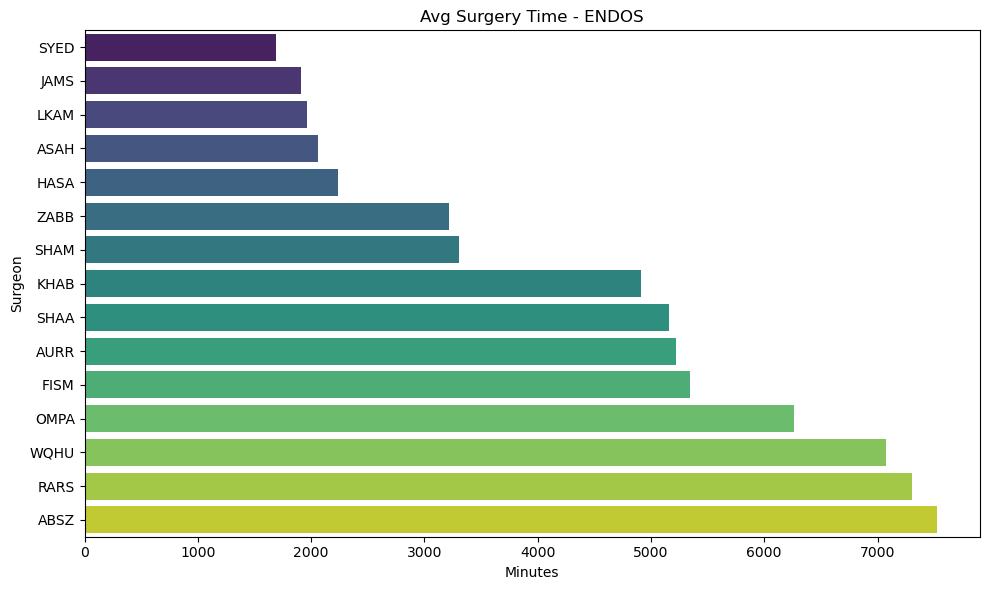

C:\Users\hfarheen\AppData\Local\Temp\ipykernel_14052\3190631124.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


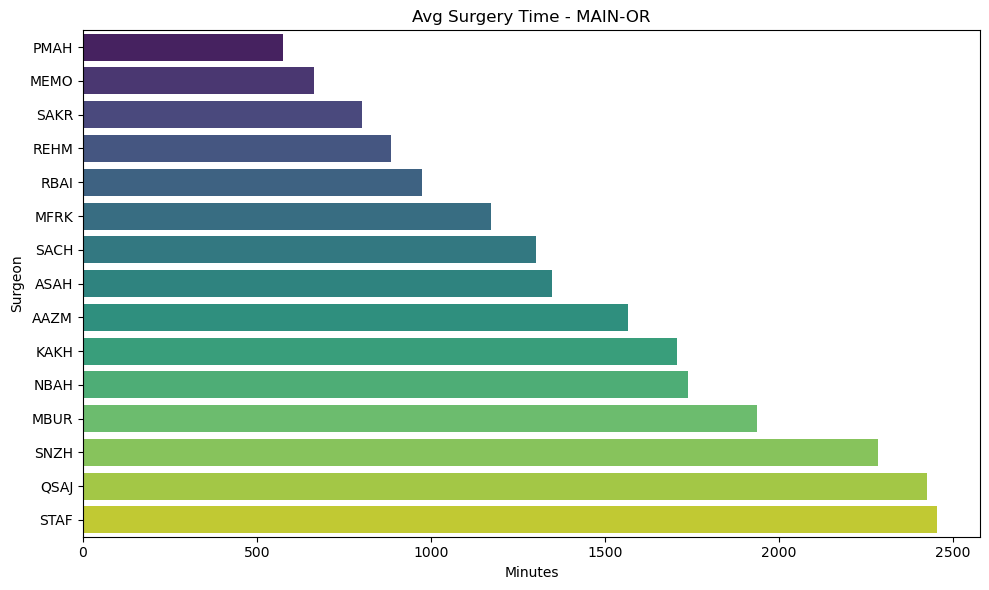

C:\Users\hfarheen\AppData\Local\Temp\ipykernel_14052\3190631124.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


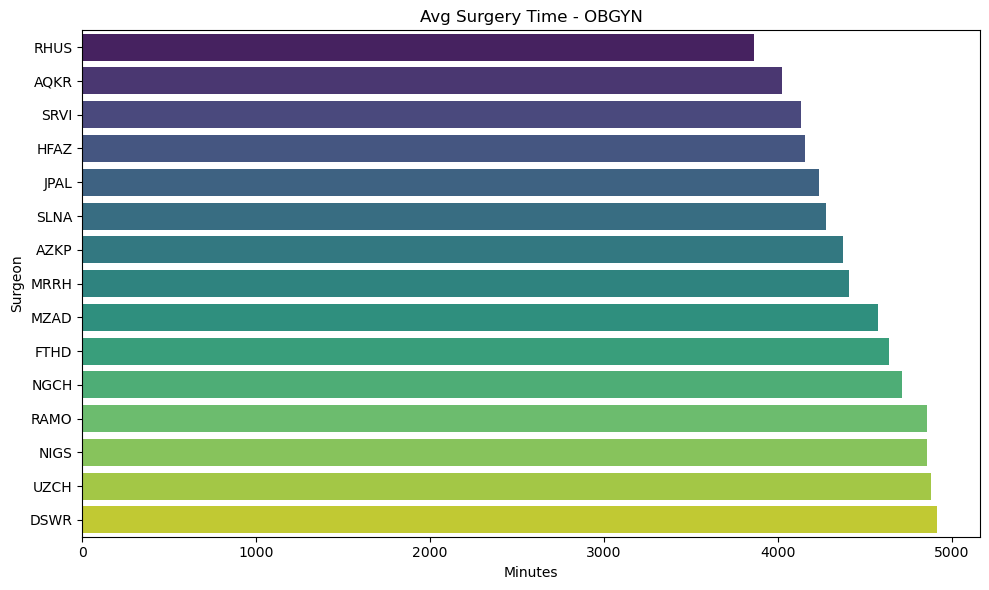

C:\Users\hfarheen\AppData\Local\Temp\ipykernel_14052\3190631124.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


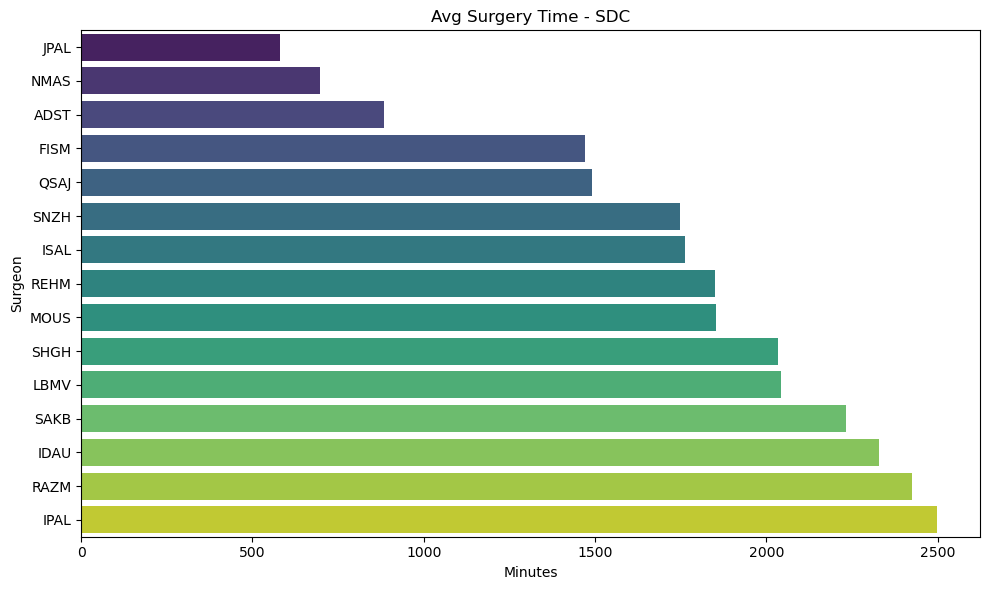

In [144]:
for loc in locations:

    df_loc = case_times[case_times['LOCATIONID'] == loc]

    plot_data = df_loc.groupby('SURGEONID')['duration_min'].mean().reset_index()
    plot_data = plot_data.sort_values('duration_min')

    # keep only top 15 fastest + slowest if needed
    plot_data = plot_data.head(15)

    plt.figure(figsize=(10,6))

    sns.barplot(
        data=plot_data,
        y='SURGEONID',
        x='duration_min',
        palette='viridis'
    )

    plt.title(f"Avg Surgery Time - {loc}")
    plt.xlabel("Minutes")
    plt.ylabel("Surgeon")

    plt.tight_layout()
    # 🔥 save file (important before show)
    filename = f"(avg_surgery_time_{loc}.png".replace(" ", "_")

    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

In [142]:
for surgeon in data['SURGEONID'].value_counts().head(5).index:

    df_s = data[data['SURGEONID'] == surgeon]

    # 2. Drop missing timestamps
    df_melt = df_melt.dropna(subset=['timestamp'])

    # 3. Rename + ordering
    df_melt['activity'] = df_melt['activity'].replace(activity_mapping)
    df_melt['activity_order'] = df_melt['activity'].map(activity_order)

    # 4. Sort events
    df_eventlog = df_melt.sort_values(
        by=['ID_seq', 'timestamp', 'activity_order']
    )

    event_log = pm4py.format_dataframe(
        df_melt,
        case_id='ID_seq',
        activity_key='activity',
        timestamp_key='timestamp'
    )

    dfg, sa, ea = pm4py.discover_performance_dfg(event_log)

    gviz = pm4py.visualization.dfg.visualizer.apply(
        dfg,
        variant=pm4py.visualization.dfg.visualizer.Variants.PERFORMANCE,
        parameters={"start_activities": sa, "end_activities": ea}
    )

    pm4py.visualization.dfg.visualizer.save(gviz, f"surgeon_{surgeon}.png")